Bir önceki seferde manuel yazdığımız kodu pytorch methodları ile daha basit yazacağız.

In [2]:
import torch 
import pandas as pd

In [ ]:
df = pd.read_csv("datas/06-study_hours_grades.csv")

In [4]:
df.head(3)

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401


In [5]:
X = torch.tensor(df["study_hours"].values, dtype = torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype = torch.float32).unsqueeze(1)

# dtype normalde float64 (double), onu  float32 yaptık
# unsqueeze 1 dim ekledik çünkü hata verdi. bu sayede [40,1] shape

In [6]:
X.shape

torch.Size([50, 1])

In [7]:
X.ndim

2

In [8]:
train_test_split = int(0.8 * len(X))
X_train, y_train = X[:train_test_split], y[:train_test_split]
X_test, y_test = X[train_test_split:], y[train_test_split:]

In [9]:
import torch.nn as nn

In [10]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features = 1,  # giren nöron 
                                      out_features = 1) # çıkan nöron


    def forward(self, x: torch.Tensor):
        return self.linear_layer(x)

nn.Linear() layer created a random weight and bias parameter for us.

In [11]:
torch.manual_seed(8)
model = LinearRegressionModel()
#  model = torch.compile(model) # -> compiler hatası almamak için sildim. normalde büyük modellerde kullanılır. şu anlık gerek yok

In [12]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [13]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.1959]])),
             ('linear_layer.bias', tensor([0.6906]))])

### Loss

In [14]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(lr = 0.01, params = model.parameters())

In [15]:
epochs = 200

for epoch in range(epochs):
    model.train()
    
    # 1-forward pass
    y_pred = model(X_train)
    
    # 2-loss calc
    loss = loss_fn(y_pred, y_train)
    
    # 3-reset optimizer
    optimizer.zero_grad()
    
    # 4-backpropogation
    loss.backward()

    # 5-optimizer weights
    optimizer.step()

    # test steps
    model.eval()
    with torch.inference_mode():
        pred = model(X_test)
        test_loss = loss_fn(pred, y_test)

    if epoch % 5 == 0:
        print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")

Epoch: 0, Train Loss: 1172.48779296875, Test Loss: 188.36770629882812
Epoch: 5, Train Loss: 22.499935150146484, Test Loss: 27.53045654296875
Epoch: 10, Train Loss: 21.34604263305664, Test Loss: 26.139989852905273
Epoch: 15, Train Loss: 20.366451263427734, Test Loss: 24.978261947631836
Epoch: 20, Train Loss: 19.441036224365234, Test Loss: 23.87737464904785
Epoch: 25, Train Loss: 18.56679344177246, Test Loss: 22.83270835876465
Epoch: 30, Train Loss: 17.740886688232422, Test Loss: 21.841262817382812
Epoch: 35, Train Loss: 16.960643768310547, Test Loss: 20.90024185180664
Epoch: 40, Train Loss: 16.223543167114258, Test Loss: 20.006973266601562
Epoch: 45, Train Loss: 15.527200698852539, Test Loss: 19.158935546875
Epoch: 50, Train Loss: 14.869359970092773, Test Loss: 18.35373878479004
Epoch: 55, Train Loss: 14.247892379760742, Test Loss: 17.589136123657227
Epoch: 60, Train Loss: 13.660791397094727, Test Loss: 16.862987518310547
Epoch: 65, Train Loss: 13.106145858764648, Test Loss: 16.17327499

In [16]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[5.4220]])),
             ('linear_layer.bias', tensor([7.2651]))])

### Prediction

In [17]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

In [18]:
for i in range(len(y_test)):
    print(f"Tahmin: {y_preds[i].item():.2f} | Gerçek: {y_test[i].item():.2f}")

Tahmin: 13.88 | Gerçek: 15.66
Tahmin: 34.11 | Gerçek: 35.47
Tahmin: 9.13 | Gerçek: 14.68
Tahmin: 56.57 | Gerçek: 54.43
Tahmin: 21.30 | Gerçek: 21.32
Tahmin: 43.19 | Gerçek: 42.12
Tahmin: 24.17 | Gerçek: 27.42
Tahmin: 35.46 | Gerçek: 36.66
Tahmin: 36.91 | Gerçek: 36.28
Tahmin: 17.29 | Gerçek: 20.27


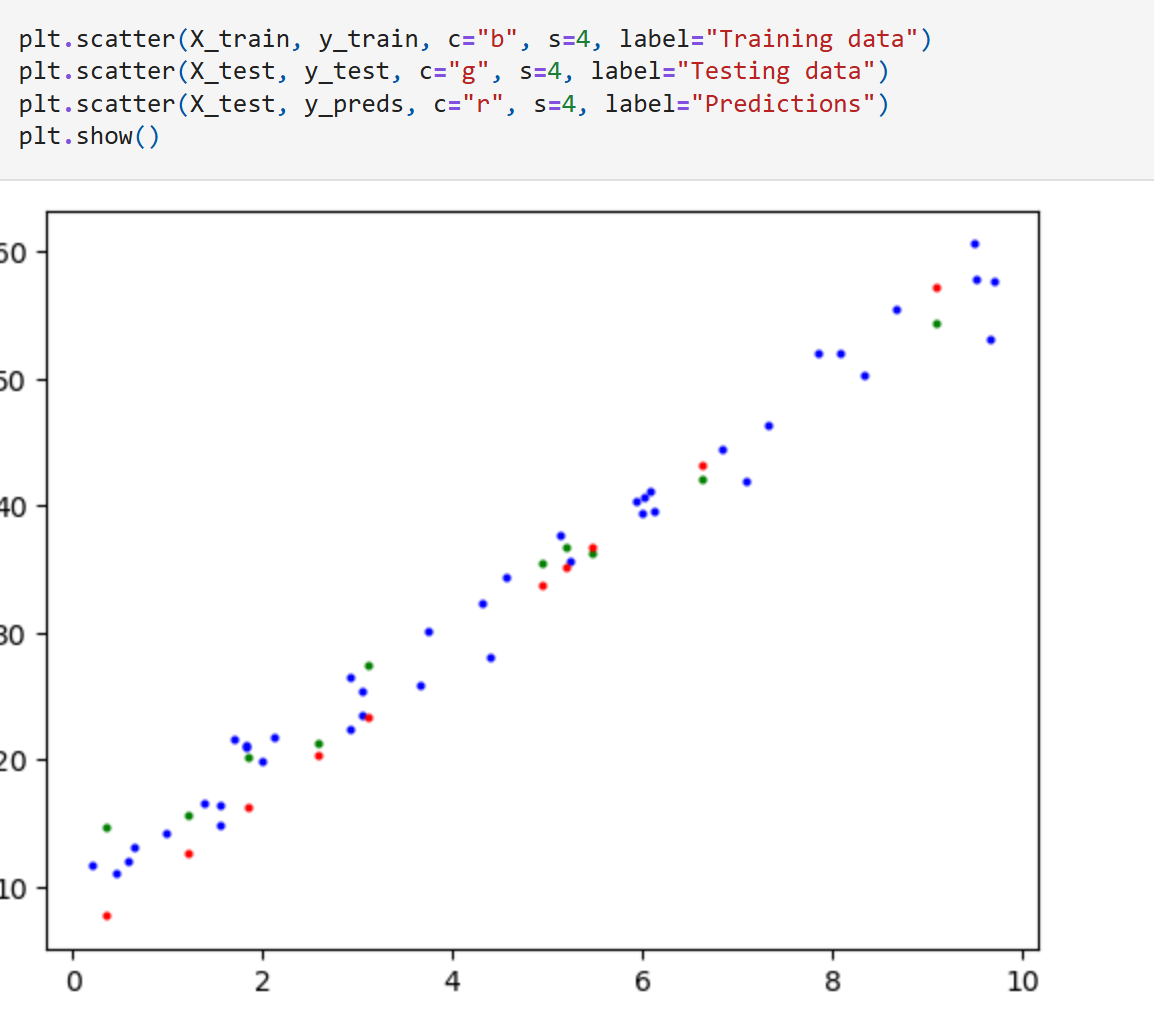